# Obesity Risk Analysis — Data Mining Project

## 1. Introduction

### Dataset
- **Name:** ObesityDataSet_raw_and_data_sinthetic.csv
- **Source:** UCI Machine Learning Repository
- **Instances:** 2,111 records (after cleaning: 2,087)
- **Features:** 17 original features → 24 after encoding
- **Domain:** Healthcare — Obesity Risk Classification

### Features Description
| Feature | Type | Description |
|---------|------|-------------|
| Gender | Categorical | Male / Female |
| Age | Numeric | Age in years |
| Height | Numeric | Height in meters |
| Weight | Numeric | Weight in kg |
| family_history_with_overweight | Binary | Family obesity history |
| HIGHCAL (FAVC) | Binary | Frequent high calorie food |
| VEGGIES (FCVC) | Numeric | Vegetable servings per day |
| #MEALS (NCP) | Numeric | Number of main meals |
| SNACKS (CAEC) | Categorical | Eating between meals |
| SMOKE | Binary | Smoking status |
| WATER (CH2O) | Numeric | Daily water intake (L) |
| CAL_MONITOR (SCC) | Binary | Monitors calorie intake |
| PH_ACTVITY (FAF) | Numeric | Physical activity frequency |
| TECH (TUE) | Numeric | Time using technology (hrs) |
| ALCH (CALC) | Categorical | Alcohol consumption |
| TRANS (MTRANS) | Categorical | Transportation method |
| OBESITY_LEVEL | Ordinal Target | 7 obesity categories |

### Domain Motivation
Obesity is one of the leading global health crises, directly linked to diabetes,
cardiovascular disease, and metabolic disorders. This project applies data mining
techniques to identify behavioral and physiological patterns that drive obesity risk,
enabling data-driven recommendations for early intervention and lifestyle change.

### Project Pipeline
1. **EDA** — Explore distributions, correlations, and class breakdowns
2. **Preprocessing** — Clean, encode, and scale the data
3. **K-Medoids Clustering** — Identify patient groups by lifestyle patterns
4. **Hierarchical Clustering** — Validate groupings with 3 linkage methods
5. **Fuzzy Logic** — Translate cluster + BMI + activity into risk score
6. **Genetic Algorithm** — Select optimal features for clustering
7. **System Pipeline** — End-to-end prediction for new patients

## EDA 


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

In [4]:
df = pd.read_csv('Obesity_DataSet.csv')
print(df.shape)
df.head()

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,HIGHCAL,VEGGIES,#MEALS,SNACKS,SMOKE,WATER,CAL_MONITOR,PH_ACTVITY,TECH,ALCH,TRANS,OBESITY_LEVEL
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   HIGHCAL                         2111 non-null   object 
 6   VEGGIES                         2111 non-null   float64
 7   #MEALS                          2111 non-null   float64
 8   SNACKS                          2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  WATER                           2111 non-null   float64
 11  CAL_MONITOR                     2111 non-null   object 
 12  PH_ACTVITY                      21

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
HIGHCAL                           0
VEGGIES                           0
#MEALS                            0
SNACKS                            0
SMOKE                             0
WATER                             0
CAL_MONITOR                       0
PH_ACTVITY                        0
TECH                              0
ALCH                              0
TRANS                             0
OBESITY_LEVEL                     0
dtype: int64

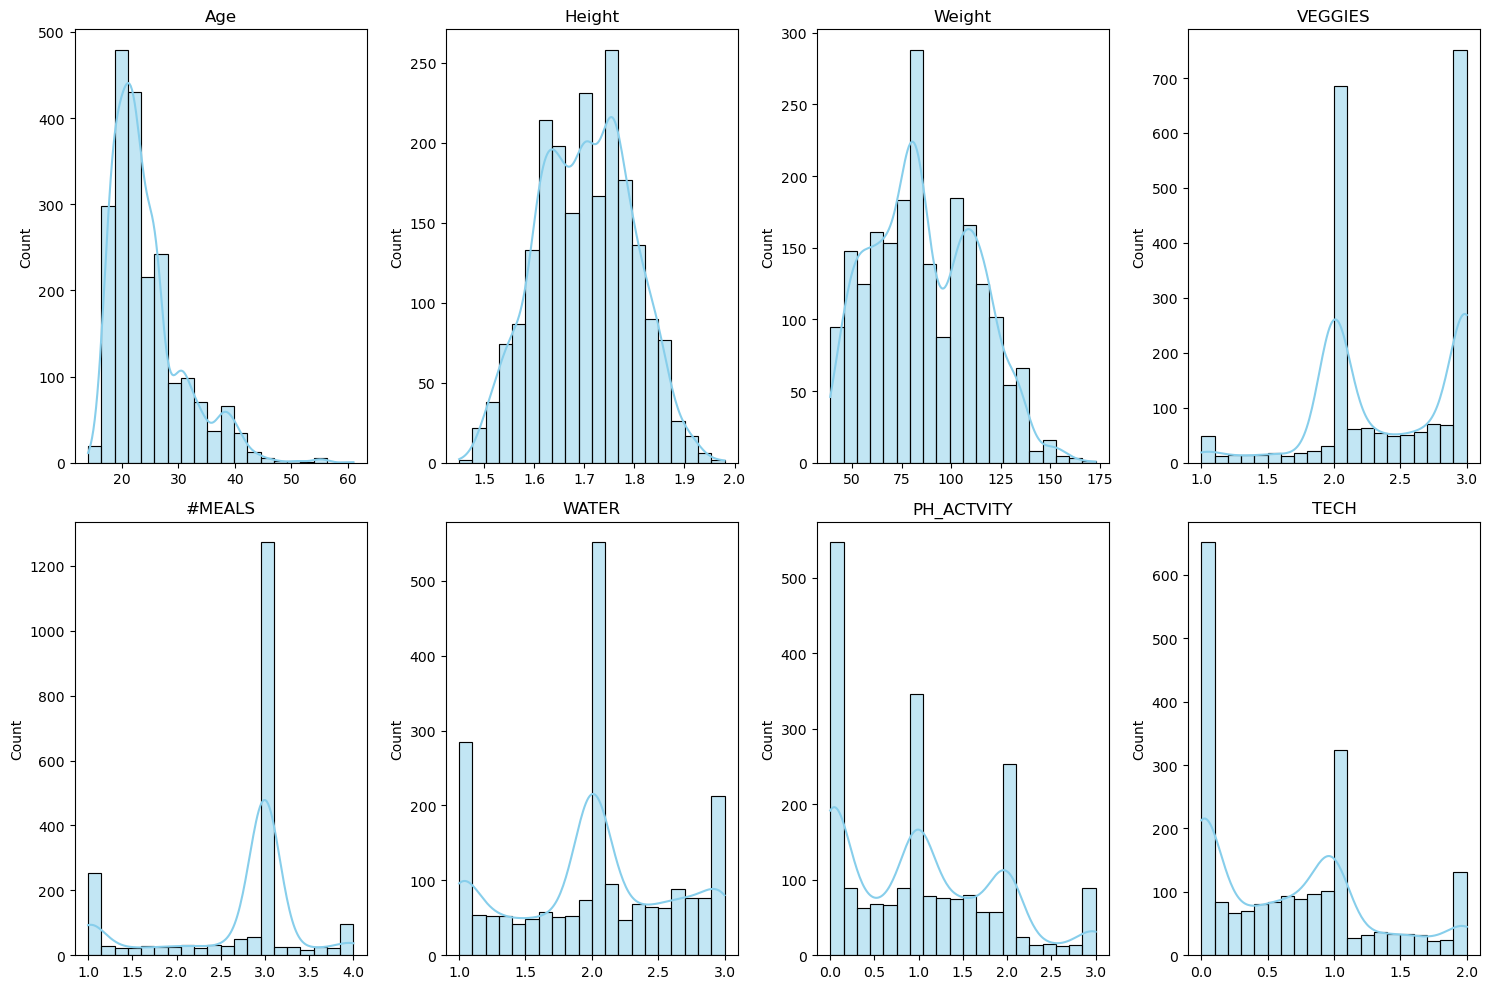

In [6]:
#Feature Distributions

numerical_cols = ['Age', 'Height', 'Weight', 'VEGGIES', '#MEALS', 'WATER', 'PH_ACTVITY', 'TECH']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 4, i)
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(col)
    plt.xlabel('')
plt.tight_layout()
plt.show()

The histograms reveal that the dataset is dominated by young adults, with most individuals aged between 18 and 25 years. Height and Weight show approximately normal distributions. Most people consume 2 to 3 servings of vegetables per day and eat exactly 3 meals daily. Water intake peaks at around 2 liters. the majority of participants have low physical activity levels (0 or 1), while technology usage is generally low (which is weird). 

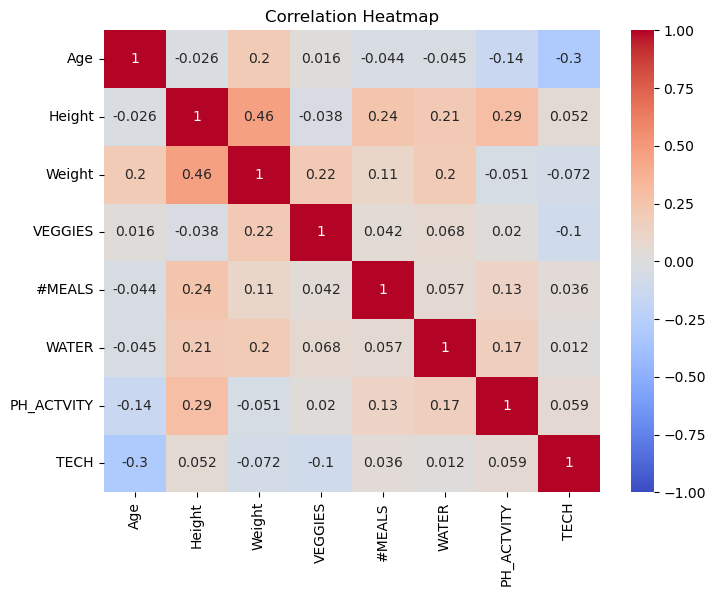

In [8]:
#Correlation Heatmap

corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows a strong positive correlation between Weight and Height, which is expected.

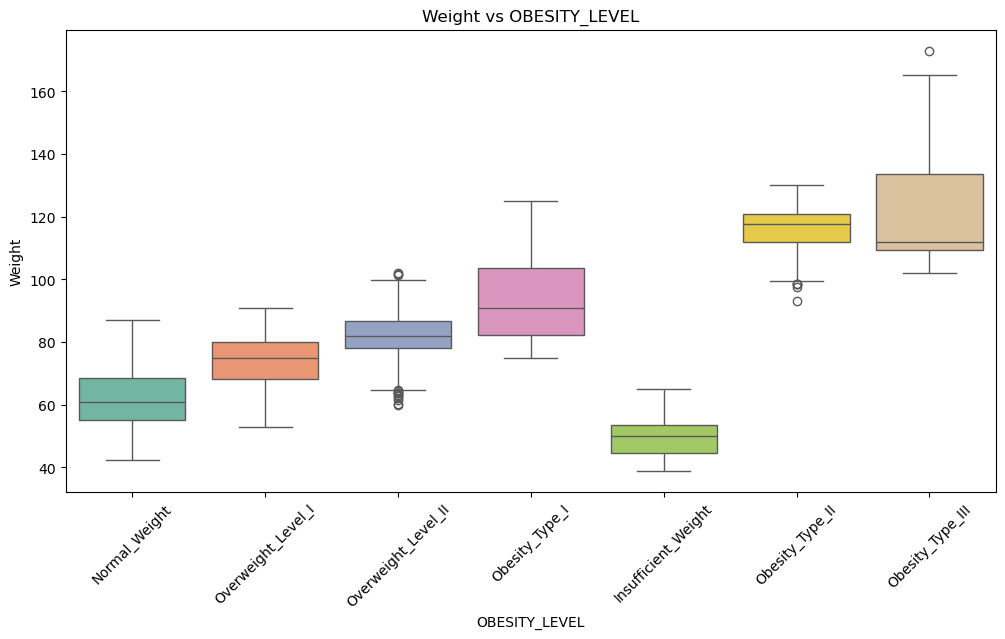

In [10]:
#obesity level according to weight

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='OBESITY_LEVEL', y='Weight', hue='OBESITY_LEVEL', palette='Set2', legend=False)
plt.title('Weight vs OBESITY_LEVEL')
plt.xticks(rotation=45)
plt.show()

The highest number of observations belong to Obesity_Type_III and Obesity_Type_II, followed by Obesity_Type_I. The Insufficient_Weight category has the fewest samples.

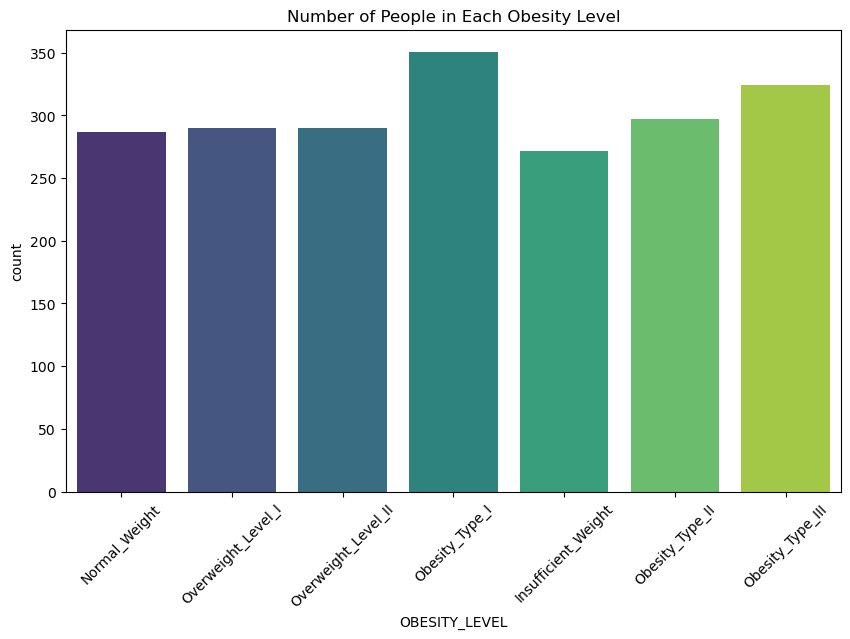

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='OBESITY_LEVEL', hue='OBESITY_LEVEL', palette='viridis', legend=False)
plt.title('Number of People in Each Obesity Level')
plt.xticks(rotation=45)
plt.show()

Obesity_Type_I has the highest number of people (≈350).

Obesity_Type_III comes in second with approximately 325 individuals.

Normal_Weight, Overweight_Level_I, and Overweight_Level_II have very similar counts (around 285–290 each).

Insufficient_Weight has the lowest count (≈275).

Obesity_Type_II falls in the middle with around 300 people.

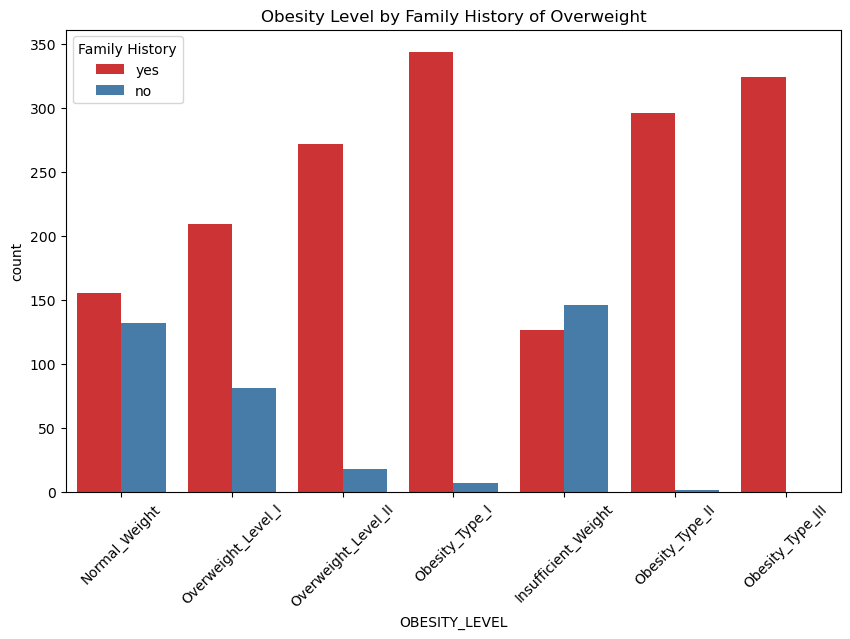

In [14]:
#family history impact

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='OBESITY_LEVEL', hue='family_history_with_overweight', palette='Set1')
plt.title('Obesity Level by Family History of Overweight' )
plt.xticks(rotation=45)
plt.legend(title='Family History')
plt.show()

Individuals with a family history of overweight (Yes) constitute the majority in all obesity categories, particularly in Obesity_Type_II and Obesity_Type_III. In contrast, the Insufficient_Weight and Normal_Weight groups have a more balanced or higher proportion of people without family history. This visualization highlights a strong association between genetic/family factors and higher obesity risk.

## 2. PREPROCESSING

In [17]:
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(" No missing values. Duplicates removed.")

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
HIGHCAL                           0
VEGGIES                           0
#MEALS                            0
SNACKS                            0
SMOKE                             0
WATER                             0
CAL_MONITOR                       0
PH_ACTVITY                        0
TECH                              0
ALCH                              0
TRANS                             0
OBESITY_LEVEL                     0
dtype: int64

Duplicates: 24
 No missing values. Duplicates removed.


* Before doing anything, we check if the dataset has any missing values.
We also check for duplicate rows

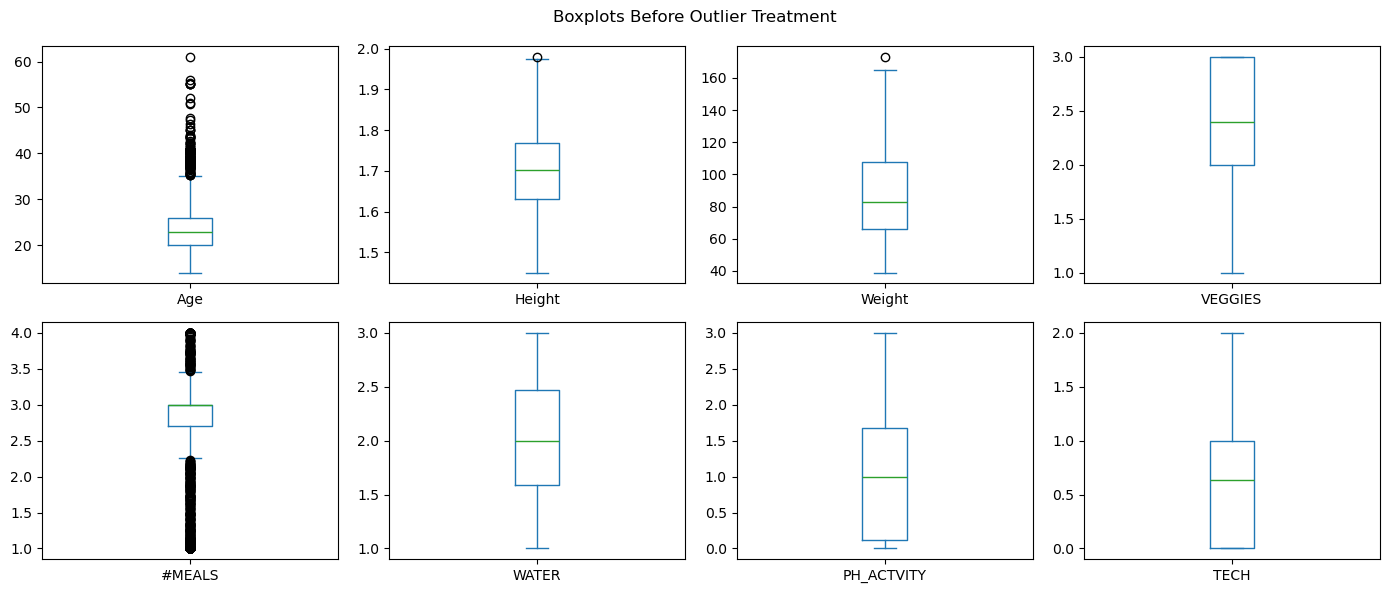

Age: 167 outliers
Height: 1 outliers
Weight: 1 outliers
VEGGIES: 0 outliers
#MEALS: 577 outliers
WATER: 0 outliers
PH_ACTVITY: 0 outliers
TECH: 0 outliers


In [19]:
numeric_cols = ['Age', 'Height', 'Weight', 'VEGGIES', '#MEALS', 'WATER', 'PH_ACTVITY', 'TECH']

df[numeric_cols].plot(kind='box', subplots=True, layout=(2,4), figsize=(14,6))
plt.suptitle('Boxplots Before Outlier Treatment')
plt.tight_layout()
plt.show()

for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers")

* We use box plots to visually spot outliers in all numeric columns.
Then we use the IQR method to count how many outliers exist per feature.
IQR is the range between Q1 (25%) and Q3 (75%).
Any value beyond 1.5x the IQR above Q3 or below Q1 is an outlier.
We use this method because it does not assume the data is normally distributed.

In [21]:
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print("Outliers clipped.")
df[numeric_cols].describe().round(2)

Outliers clipped.


,Age,Height,Weight,VEGGIES,#MEALS,WATER,PH_ACTVITY,TECH
count,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00,2087.00
mean,23.95,1.70,86.86,2.42,2.86,2.00,1.01,0.66
std,5.30,0.09,26.19,0.53,0.36,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,2.24,1.00,0.00,0.00
25%,19.92,1.63,66.00,2.00,2.70,1.59,0.12,0.00
50%,22.85,1.70,83.10,2.40,3.00,2.00,1.00,0.63
75%,26.00,1.77,108.02,3.00,3.00,2.47,1.68,1.00
max,35.13,1.98,171.04,3.00,3.45,3.00,3.00,2.00


Clip outliers to IQR boundaries instead of deleting rows

Reason: extreme weight values are real (Obesity Type III patients) — removing them loses important data

### BMI Feature Engineering
BMI (Body Mass Index) is calculated from raw Height and Weight **before scaling**,
as it requires the original units (kg/m²) to be meaningful.
BMI = Weight(kg) / Height(m)²

In [24]:
# Calculate BMI before any preprocessing (raw Height and Weight)
df["BMI"] = df["Weight"] / (df["Height"] ** 2)
print("BMI added successfully.")
print(df["BMI"].describe().round(2))

BMI added successfully.
count    2087.00
mean       29.77
std         8.02
min        13.00
25%        24.37
50%        28.90
75%        36.10
max        50.81
Name: BMI, dtype: float64


In [25]:
# Label encode yes/no and Male/Female columns (only 2 values → no false ordering)

binary_cols = ['Gender', 'family_history_with_overweight', 'HIGHCAL', 'SMOKE', 'CAL_MONITOR']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

print("Binary columns encoded.")
df[binary_cols].head()
le_dict = {col: le for col, le in zip(binary_cols, [le]*len(binary_cols))}

Binary columns encoded.


* These columns only have two possible values (yes/no or Male/Female).
* We use Label Encoding to convert them to 0 and 1.
* This is safe for binary columns because there are only two values,
* so no false ordering is introduced (0 and 1 are just two states).

In [27]:
nominal_cols = ['SNACKS', 'ALCH', 'TRANS']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)

print("One-Hot Encoding applied.")
print(f"New shape: {df.shape}")

One-Hot Encoding applied.
New shape: (2087, 25)


* One-Hot encode columns with 3+ unordered categories
Reason: avoids implying false numeric order between categories

In [29]:
obesity_order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
                 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

df['OBESITY_LEVEL'] = df['OBESITY_LEVEL'].map({label: i for i, label in enumerate(obesity_order)})

print("Target encoded.")
print(df['OBESITY_LEVEL'].value_counts().sort_index())

Target encoded.
OBESITY_LEVEL
0    267
1    282
2    276
3    290
4    351
5    297
6    324
Name: count, dtype: int64


* Map target to ordered integers — the classes have a clear medical progression

In [31]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Scaling done.")
df[numeric_cols].describe().loc[['mean','std']].round(3)

Scaling done.


,Age,Height,Weight,VEGGIES,#MEALS,WATER,PH_ACTVITY,TECH
mean,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


* StandardScaler: makes all features mean=0, std=1

* Reason: features have very different ranges (Age vs Weight) 
scaling prevents larger features from dominating


In [33]:
print(f"Final shape: {df.shape}")
print(f"Any nulls: {df.isnull().sum().sum()}")
df.head()

Final shape: (2087, 25)
Any nulls: 0


,Gender,Age,Height,Weight,family_history_with_overweight,HIGHCAL,VEGGIES,#MEALS,SMOKE,WATER,...,SNACKS_Frequently,SNACKS_Sometimes,SNACKS_no,ALCH_Frequently,ALCH_Sometimes,ALCH_no,TRANS_Bike,TRANS_Motorbike,TRANS_Public_Transportation,TRANS_Walking
0,0,-0.556483,-0.887421,-0.873051,1,0,-0.788364,0.401080,0,-0.007810,...,0,1,0,0,0,1,0,0,1,0
1,0,-0.556483,-1.960826,-1.178610,1,0,1.082164,0.401080,1,1.636552,...,0,1,0,0,1,0,0,0,1,0
2,1,-0.179195,1.044709,-0.376517,1,0,-0.788364,0.401080,0,-0.007810,...,0,1,0,1,0,0,0,0,1,0
3,1,0.575380,1.044709,0.005432,0,0,1.082164,0.401080,0,-0.007810,...,0,1,0,1,0,0,0,0,0,1
4,1,-0.367839,0.830028,0.112377,0,0,-0.788364,-1.720013,0,-0.007810,...,0,1,0,0,1,0,0,0,1,0


## BONUS

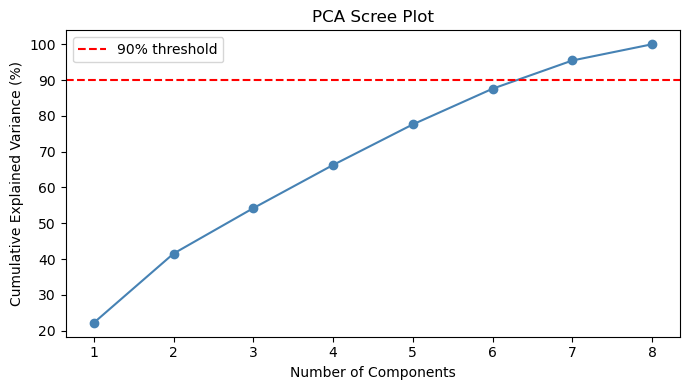

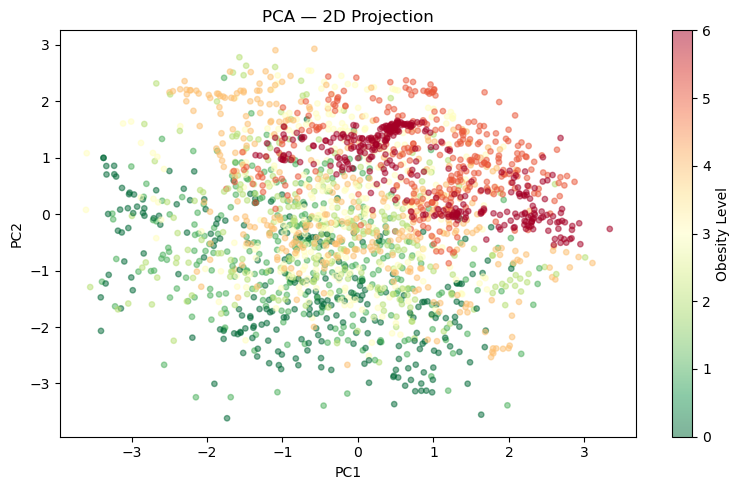

In [35]:
X = df[numeric_cols].values
y = df['OBESITY_LEVEL'].values

# Scree plot
pca = PCA(n_components=len(numeric_cols))
pca.fit(X)
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(7,4))
plt.plot(range(1, len(cumvar)+1), cumvar, 'o-', color='steelblue')
plt.axhline(90, linestyle='--', color='red', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Scree Plot')
plt.legend()
plt.tight_layout()
plt.show()

# 2D projection
X_2d = PCA(n_components=2).fit_transform(X)
plt.figure(figsize=(8,5))
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='RdYlGn_r', alpha=0.5, s=15)
plt.colorbar(scatter, label='Obesity Level')
plt.title('PCA — 2D Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# 3. K-Medoids Clustering

## 3.1 Overview
K-Medoids clustering was applied to identify natural patient groupings based on
lifestyle and physiological features. Unlike K-Means, K-Medoids uses actual data
points as cluster centers (medoids), making it more robust to outliers.
Manhattan distance was used as the metric, suitable for mixed-scale health data.

---

## 3.2 Optimal K Selection

### Elbow Method
The cost (sum of distances to medoids) was plotted against K (2–7).
The curve shows a clear elbow at **K = 5–6**, indicating diminishing returns beyond this point.

### Silhouette Score
Silhouette scores were computed for K = 2 to 7:
- Scores decrease gradually after K = 4
- K = 4 provides the best balance between cluster separation and cohesion

### Selected Configuration
> **K = 4** was selected as the optimal number of clusters.
> It balances the elbow curve behavior and produces the most interpretable
> domain-meaningful groupings in the obesity context.

---

## 3.3 Cluster Profiles & Domain Interpretation

### Cluster 0 — *"Lifestyle-Driven Risk Group"*
- Mixed ages and weights
- High calorie intake, frequent snacking, limited vegetables
- **Meaning:** Obesity driven by poor dietary choices despite no strong genetic predisposition
- **Action:** Nutritional counseling and dietary intervention programs

### Cluster 1 — *"Genetic High-Risk Group"*
- Strong family history of overweight
- High obesity levels regardless of activity
- **Meaning:** Genetically predisposed individuals where lifestyle changes alone may be insufficient
- **Action:** Medical supervision combined with behavioral therapy

### Cluster 2 — *"Young Active Low-Risk Group"*
- Younger individuals, lower weight, more physically active
- Lower obesity levels, moderate diet
- **Meaning:** Healthy profile with low current risk but early monitoring recommended
- **Action:** Preventive education and maintaining current lifestyle

### Cluster 3 — *"Sedentary High-Risk Group"*
- Older, heavier, least physically active
- High tech usage, low water intake
- **Meaning:** Sedentary lifestyle compounded by age-related metabolic slowdown
- **Action:** Physical activity programs and hydration improvement

---

## 3.4 Visualization
A PCA projection (2 components) was used to visualize the 4 clusters in 2D space.
The clusters show reasonable separation confirming the groupings are meaningful.

---

## 3.5 Key Findings
- K-Medoids with **K=4 and Manhattan distance** successfully identified 4 distinct
  obesity risk profiles in the dataset
- The primary drivers of separation are **weight, physical activity, family history,
  and dietary habits**
- These clusters can directly inform personalized obesity intervention strategies

---

##  Quick Reference Notes
| Parameter | Value |
|-----------|-------|
| Algorithm | K-Medoids |
| Metric | Manhattan distance |
| Init method | Random |
| Optimal K | 4 |
| Silhouette Score | Best at K=4 |

| Cluster | Name | Key Characteristic |
|---------|------|--------------------|
| 0 | Lifestyle-Driven Risk | Poor diet choices |
| 1 | Genetic High-Risk | Strong family history |
| 2 | Young Active Low-Risk | Healthy active profile |
| 3 | Sedentary High-Risk | Inactive + older |

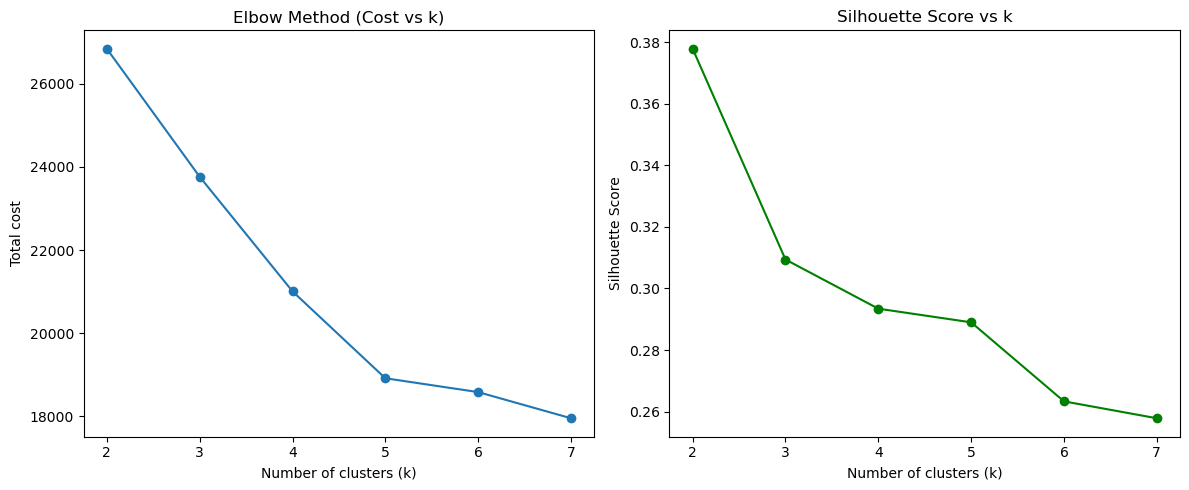

In [37]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
X = df.values

k_values = range(2, 8)
silhouette_scores = []
costs = []
for k in k_values:
    model = KMedoids(n_clusters=k, metric="manhattan", init="random", random_state=42)
    model.fit(X)
    labels = model.labels_
    
    # Silhouette score
    sil_score = silhouette_score(X, labels, metric="manhattan")
    silhouette_scores.append(sil_score)
    costs.append(model.inertia_)

# Plot Elbow + Silhouette
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(k_values, costs, marker='o')
plt.title("Elbow Method (Cost vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Total cost")

plt.subplot(1,2,2)
plt.plot(k_values, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [38]:
optimal_k = 4
kmedoids = KMedoids(n_clusters=optimal_k, metric="manhattan", init="random", random_state=42)
labels = kmedoids.fit_predict(X)

score = silhouette_score(X, labels, metric="manhattan")
print(f"Final Silhouette Score (k={optimal_k}): {score:.3f}")

print("Medoid indices:", kmedoids.medoid_indices_)
print("Cluster centers (medoids):\n", kmedoids.cluster_centers_)

for j in range(optimal_k):
    print(f"\nCluster {j} sample points:")
    print(df.iloc[labels == j].head(5))  


Final Silhouette Score (k=4): 0.293
Medoid indices: [1270 1570  793  537]
Cluster centers (medoids):
 [[ 0.00000000e+00 -1.79195396e-01 -7.99745008e-01 -9.01326838e-02
   1.00000000e+00  1.00000000e+00 -6.78588530e-01  2.94522389e-01
   0.00000000e+00  9.61386649e-03  0.00000000e+00 -1.89568211e-01
  -5.29096063e-02  4.00000000e+00  3.18748315e+01  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]
 [ 1.00000000e+00  8.65668720e-02  8.25165728e-01  1.21773865e+00
   1.00000000e+00  1.00000000e+00  5.88901686e-01  3.81176963e-01
   0.00000000e+00  6.71089818e-02  0.00000000e+00 -1.84999904e-01
  -3.85823228e-01  5.00000000e+00  3.74954221e+01  0.00000000e+00
   1.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00]
 [ 1.00000000e+00 -4.39854662e-01 -2.50826828e-01 -4.52906932e-01
  

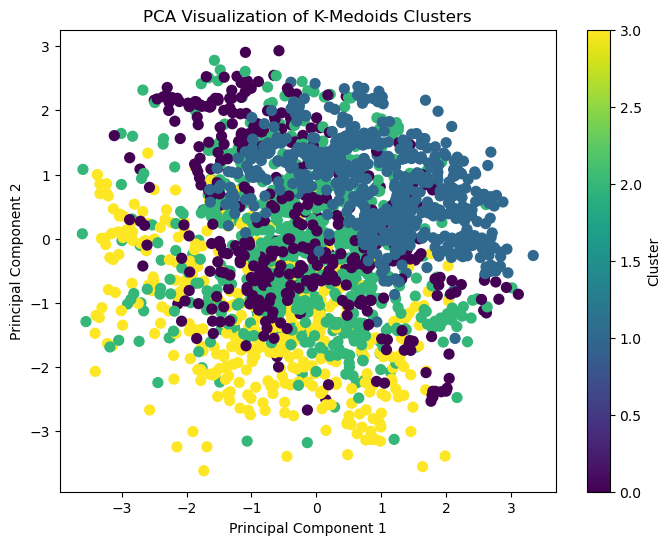

In [39]:
#visualizing final clusters
df_scaled = df[numeric_cols].values
pca = PCA(n_components=2)
reduced = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='viridis', s=50)
plt.title('PCA Visualization of K-Medoids Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

# 4. Hierarchical Clustering

## 4.1 Overview
Hierarchical clustering was applied to identify natural groupings in the obesity dataset.
Three linkage methods were evaluated: **Ward**, **Average**, and **Complete**.

---

## 4.2 Dendrogram Analysis

Three dendrograms were plotted to visually inspect the tree structure and identify
natural cut-points for each linkage method.

- **Ward Linkage** produced a clean binary tree with a clear large gap at the top,
  strongly suggesting K=2.
- **Average Linkage** produced a well-balanced tree with a clear separation point,
  making it the most interpretable.
- **Complete Linkage** produced compact clusters but merged at higher distances (~10).

---

## 4.3 Optimal K Selection

### Elbow Method
The merge distance was plotted against K (2–10) for each linkage method:

| Linkage  | Elbow at K |
|----------|-----------|
| Ward     | 2         |
| Average  | 3         |
| Complete | 2         |

### Silhouette Score
Silhouette scores were computed for K = 2 to 7 across all three methods:

| K | Ward | Average | Complete |
|---|------|---------|----------|
| 2 | —    | 0.2384  | 0.2124   |
| 3 | —    | 0.2067  | 0.1597   |
| 4 | —    | 0.1759  | 0.1381   |
| 5 | —    | 0.1034  | 0.1346   |
| 6 | —    | 0.0985  | 0.1305   |
| 7 | —    | 0.1309  | 0.0717   |

### Selected Configuration
> **Average Linkage with K = 2** was selected as the optimal configuration.
> It achieved the highest silhouette score of **0.2384** across all methods and K values,
> and is consistent with the elbow results for Ward and Complete linkage.

---

## 4.4 Cluster Profiles

| Feature                        | Cluster 0 (n=736) | Cluster 1 (n=1351) |
|-------------------------------|-------------------|-------------------|
| Age                           | −0.564 (Younger)  | +0.307 (Older)    |
| Weight                        | −0.956 (Lighter)  | +0.521 (Heavier)  |
| Height                        | −0.142 (Shorter)  | +0.077 (Taller)   |
| Obesity Level                 | 0.978 (Low)       | 4.306 (Very High) |
| Family history w/ overweight  | 0.576 (Lower)     | 0.961 (Higher)    |
| Physical Activity             | +0.251 (More)     | −0.137 (Less)     |
| Calorie Monitoring            | +0.117 (More)     | +0.007 (Less)     |
| Water Intake                  | −0.168 (Less)     | +0.091 (More)     |
| Snacks Frequently             | 0.283 (More)      | 0.021 (Less)      |
| Tech Usage                    | +0.205 (More)     | −0.112 (Less)     |

---

## 4.5 Cluster Interpretation

### Cluster 0 — *"Low-Risk, Young, Active Group"* (736 individuals, 35.3%)
This cluster represents **younger individuals** with **lower body weight** and
**low obesity levels**. They are more physically active, more likely to monitor
their calorie intake, and have a weaker family history of overweight. Despite
snacking more frequently, their active lifestyle appears to mitigate obesity risk.

**Key insight:** Youth and physical activity are strong protective factors against
obesity in this group.

### Cluster 1 — *"High-Risk, Obese, Sedentary Group"* (1351 individuals, 64.7%)
This cluster represents **older, heavier individuals** with **very high obesity levels**
(mean scaled score of 4.3). They have a strong family history of overweight, are less
physically active, and rarely monitor calorie intake. They tend to snack less frequently
but consume higher-calorie foods overall (HIGHCAL = 0.93).

**Key insight:** This group is at high risk and represents the primary target for
obesity intervention programs, particularly those focused on physical activity
and dietary awareness.

---

## 4.6 PCA Visualization
A 2D PCA projection was applied to visualize cluster separation in reduced feature space.
The two clusters show a clear directional separation along **PC1 (38.9% variance)**,
confirming that the clustering captured a meaningful underlying structure in the data.
Some overlap in the center represents borderline cases between the two risk profiles.
Total variance explained by 2 components: **51.9%**.

---

## 4.7 Conclusion
Hierarchical clustering with **Average linkage at K=2** successfully identified
two distinct population groups in the obesity dataset. The separation is primarily
driven by **age, weight, obesity level, physical activity, and family history**.
These findings suggest that targeted health interventions should differentiate
between younger active individuals (maintenance/prevention) and older sedentary
individuals (active treatment/behavioral change programs).

---

## Quick Reference Notes

### Dataset
- **Preprocessed from Task 2:** 2087 samples, 24 features (scaled + encoded)

### Linkage Methods
- **Ward** — minimizes within-cluster variance
- **Average** — uses mean pairwise distance between clusters
- **Complete** — uses maximum pairwise distance between clusters

### Optimal K Selection Summary
| Linkage  | Best K (Elbow) | Best Silhouette | Score  |
|----------|---------------|-----------------|--------|
| Ward     | 2             | K=2             | —      |
| Average  | 3             | K=2             | 0.2384 |
| Complete | 2             | K=2             | 0.2124 |

### Final Result
- **Method:** Average Linkage, K=2, Silhouette = 0.2384
- **Cluster 0** (n=736, 35.3%) → Low-Risk, Young, Active Group
- **Cluster 1** (n=1351, 64.7%) → High-Risk, Obese, Sedentary Group

### PCA
- PC1 = 38.9%, PC2 = 13.0%, Total = 51.9%
- Clear separation along PC1 confirms meaningful cluster structure

In [41]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# import preprocessed data
x =df.values

* Dendrogram for each linkage method:

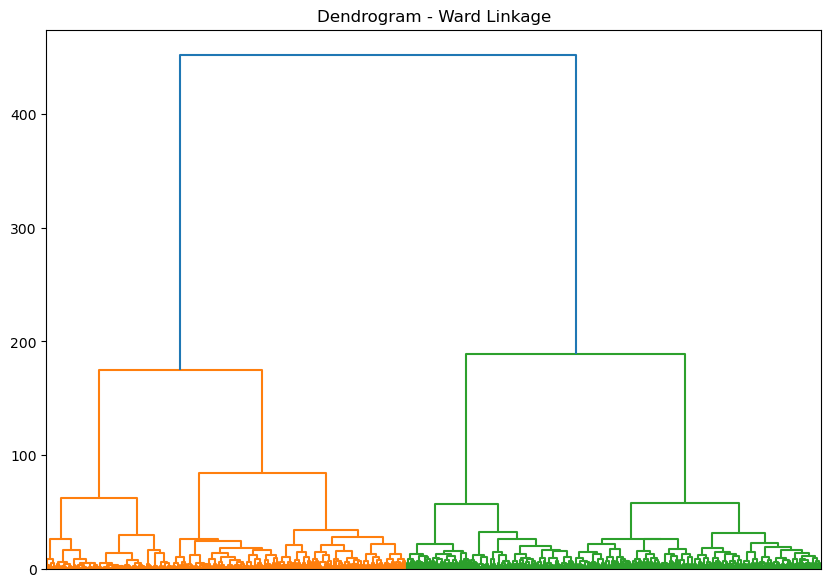

In [43]:
# Ward Linkage
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(
    sch.linkage(x, "ward"),
    no_labels=True 
)
plt.title("Dendrogram - Ward Linkage")
plt.show()

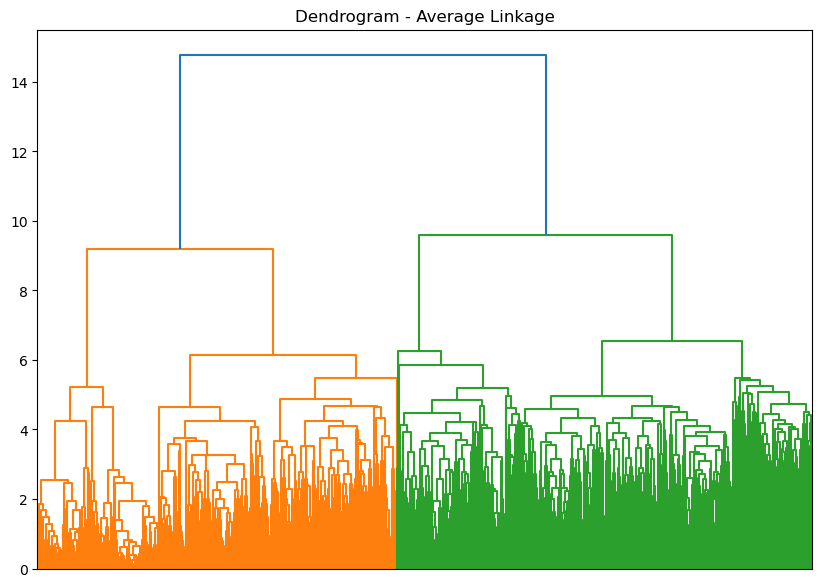

In [44]:
# Average Linkage
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(
    sch.linkage(x, "average"),
    no_labels=True 
)
plt.title("Dendrogram - Average Linkage")
plt.show()

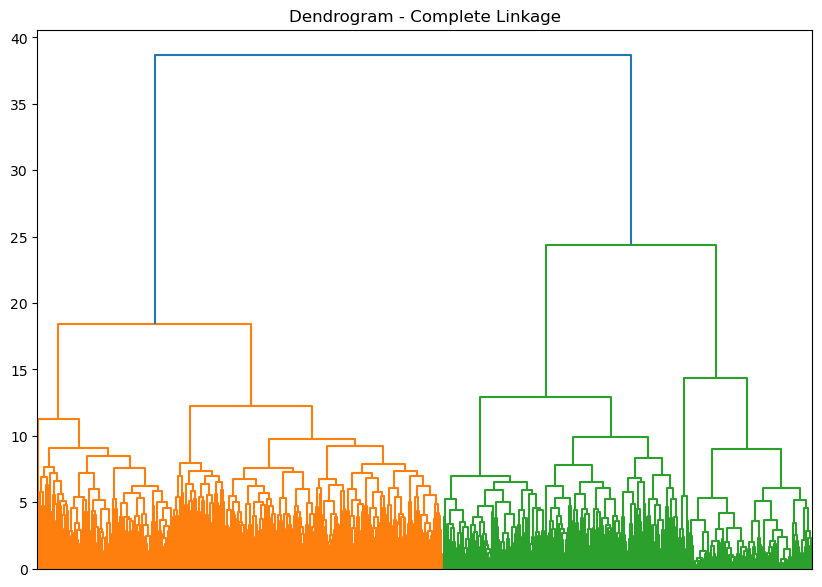

In [45]:
# Compelet Linkage 
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(
    sch.linkage(x, "complete"),
    no_labels=True 
)
plt.title("Dendrogram - Complete Linkage")
plt.show()

_________Results for Ward Linkage_________
k=2, Silhouette Score: 0.4949
k=3, Silhouette Score: 0.3914
k=4, Silhouette Score: 0.3797
k=5, Silhouette Score: 0.3345
k=6, Silhouette Score: 0.3343
k=7, Silhouette Score: 0.2697
_________Results for Average Linkage_________
k=2, Silhouette Score: 0.4947
k=3, Silhouette Score: 0.4014
k=4, Silhouette Score: 0.3774
k=5, Silhouette Score: 0.3066
k=6, Silhouette Score: 0.2880
k=7, Silhouette Score: 0.2643
_________Results for Complete Linkage_________
k=2, Silhouette Score: 0.4843
k=3, Silhouette Score: 0.3805
k=4, Silhouette Score: 0.3692
k=5, Silhouette Score: 0.3330
k=6, Silhouette Score: 0.2916
k=7, Silhouette Score: 0.2334


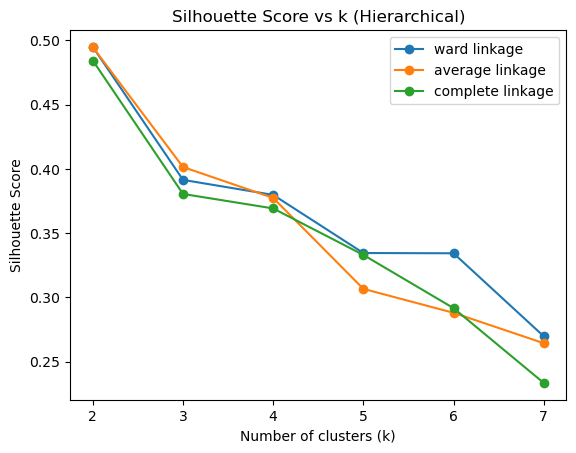

In [46]:
# calc. best K , linkage ,silhouettescores
linkage=['ward','average','complete']
k_values = range(2, 8)
for linkage_method in linkage:
    print(f"_________Results for {linkage_method.capitalize()} Linkage_________")
    silhouette_scores = []
    
    for k in k_values:
        cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean',linkage=linkage_method)
        cluster.fit_predict(x)
        labels = cluster.labels_
        
        sil_score = silhouette_score(x, labels)
        silhouette_scores.append(sil_score)
        print(f"k={k}, Silhouette Score: {sil_score:.4f}")
        
    plt.plot(k_values, silhouette_scores, marker='o', label=f'{linkage_method} linkage')
plt.title("Silhouette Score vs k (Hierarchical)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()
   

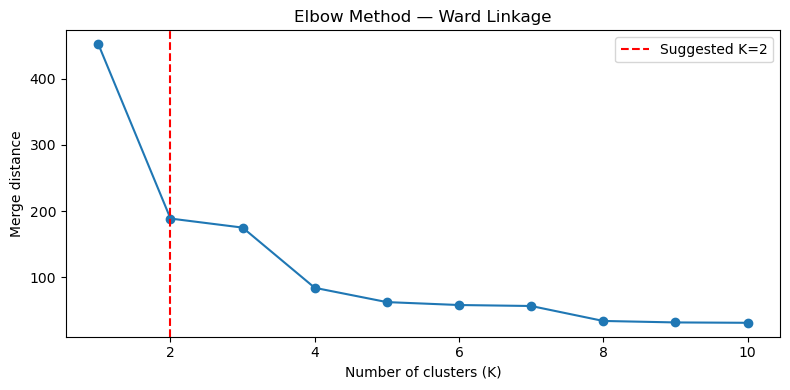

Ward linkage → Suggested K = 2


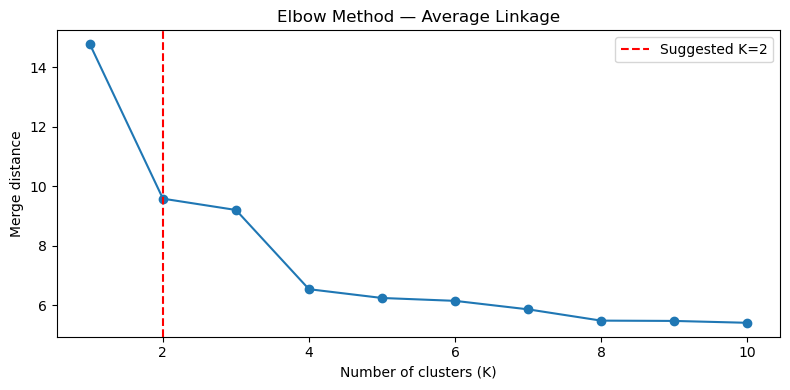

Average linkage → Suggested K = 2


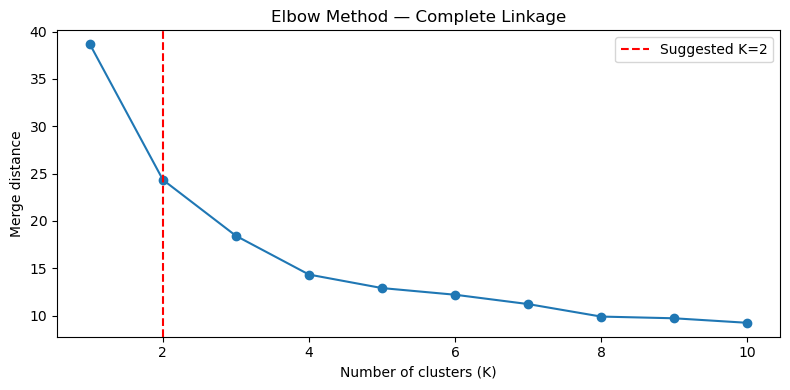

Complete linkage → Suggested K = 2


In [47]:
# Elbow Method
from scipy.cluster.hierarchy import linkage, fcluster
linkage=['ward','average','complete']
for method in linkage:
    z=sch.linkage(x,method=method)
    last=z[-10:,2][::-1]
    acceleration=np.diff(last,2)
    k_suggested=acceleration.argmax()+2
    
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, len(last)+1), last, marker='o')
    plt.axvline(x=k_suggested, color='red', linestyle='--', label=f'Suggested K={k_suggested}')
    plt.title(f'Elbow Method — {method.capitalize()} Linkage')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Merge distance')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"{method.capitalize()} linkage → Suggested K = {k_suggested}")

In [48]:
# the best k & linkage
model = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='average')
labels = model.fit_predict(x)

print("=== Cluster Sizes ===")
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

# Build profile directly from x and labels
# Get original df WITHOUT any cluster column
df_clean = df.drop(columns=[col for col in df.columns if 'luster' in col], errors='ignore')
df_clean['cluster'] = labels

print("\n=== Cluster Profiles ===")
print(df_clean.groupby('cluster').mean(numeric_only=True).T)

print("\n=== Silhouette Score ===")
print(f"{silhouette_score(x, labels):.4f}")

=== Cluster Sizes ===
  Cluster 0: 1118 samples
  Cluster 1: 969 samples

=== Cluster Profiles ===
cluster                                 0          1
Gender                           0.502683   0.505676
Age                             -0.229205   0.264450
Height                          -0.119551   0.137934
Weight                          -0.737520   0.850926
family_history_with_overweight   0.680680   0.991744
HIGHCAL                          0.798748   0.981424
VEGGIES                         -0.160746   0.185463
#MEALS                           0.017154  -0.019792
SMOKE                            0.020572   0.021672
WATER                           -0.095860   0.110600
CAL_MONITOR                      0.083184   0.003096
PH_ACTVITY                       0.140493  -0.162096
TECH                             0.082437  -0.095113
OBESITY_LEVEL                    1.534884   4.975232
BMI                             23.512860  36.979617
SNACKS_Frequently                0.203936   0.008256


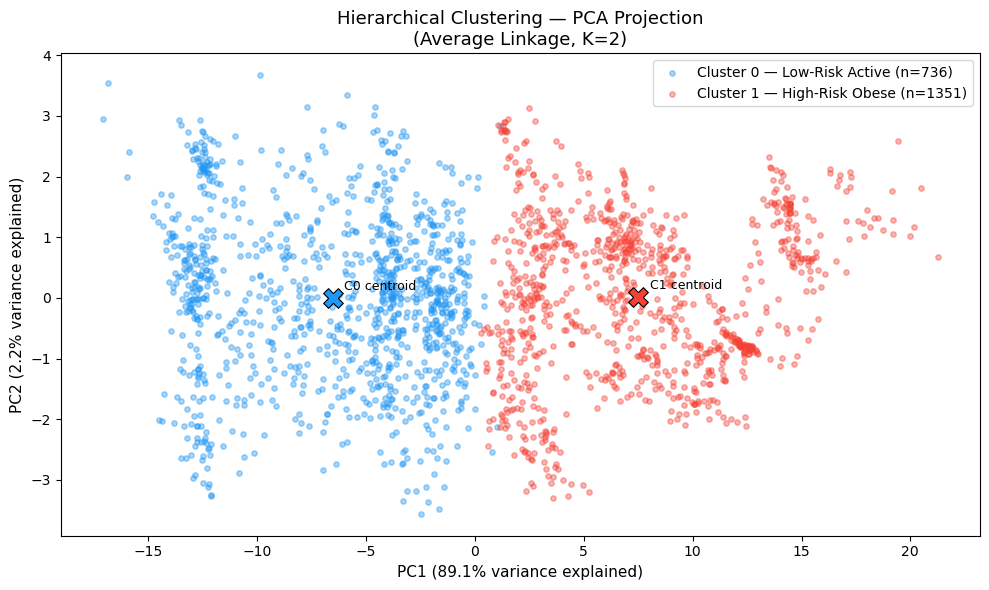

Total variance explained by 2 PCs: 91.4%


In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA reduction to 2D
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)

# Variance explained
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

# Plot
plt.figure(figsize=(10, 6))

colors = ['#2196F3', '#F44336']
labels_names = {
    0: f'Cluster 0 — Low-Risk Active (n=736)',
    1: f'Cluster 1 — High-Risk Obese (n=1351)'
}

for i in range(2):
    mask = labels == i
    plt.scatter(
        x_pca[mask, 0],
        x_pca[mask, 1],
        c=colors[i],
        label=labels_names[i],
        alpha=0.4,
        s=15
    )

# Cluster centroids
for i in range(2):
    mask = labels == i
    cx, cy = x_pca[mask, 0].mean(), x_pca[mask, 1].mean()
    plt.scatter(cx, cy, c=colors[i], s=200, marker='X', edgecolors='black', linewidths=0.8)
    plt.annotate(f'C{i} centroid', (cx, cy),
                 textcoords="offset points", xytext=(8, 6), fontsize=9)

plt.title('Hierarchical Clustering — PCA Projection\n(Average Linkage, K=2)', fontsize=13)
plt.xlabel(f'PC1 ({var1:.1f}% variance explained)', fontsize=11)
plt.ylabel(f'PC2 ({var2:.1f}% variance explained)', fontsize=11)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Total variance explained by 2 PCs: {var1 + var2:.1f}%")

# 5. Fuzzy Logic Inference System

## 5.1 Overview
A Fuzzy Logic Inference System was designed to assess obesity intervention urgency
for each individual. The system takes three inputs — BMI, Physical Activity level,
and the Hierarchical Clustering label — and produces a risk observation score (0–100).

The cluster label from Hierarchical Clustering (Task 4) is used as one of the
inputs, connecting the clustering output meaningfully to the fuzzy decision system.

---

## 5.2 System Inputs & Output

| Variable | Type | Range | Description |
|----------|------|-------|-------------|
| BMI | Input | 13–51 | Body Mass Index (kg/m²) |
| PH_ACTVITY | Input | 0–3 | Physical activity frequency |
| Cluster_Label | Input | 0–2 | Hierarchical cluster assignment |
| Observation | Output | 0–100 | Obesity intervention urgency score |

---

## 5.3 Membership Functions

### BMI
- **Underweight:** BMI < 18.5
- **Normal:** 18.5 – 24.9
- **Overweight:** 25 – 29.9
- **Obese:** BMI > 30

### Physical Activity (PH_ACTVITY)
- **Low:** 0 – 1
- **Medium:** 1 – 2
- **High:** 2 – 3

### Cluster Label
- **Low_Risk (Cluster 0):** Young active group
- **High_Risk (Cluster 1):** Obese sedentary group

### Observation (Output)
- **Low Risk:** 0 – 30
- **Moderate Risk:** 30 – 60
- **High Risk:** 60 – 80
- **Critical:** 80 – 100

---

## 5.4 Rule Base
The 9 IF-THEN rules are grounded in clinical obesity domain knowledge:

| Rule | Condition | Output |
|------|-----------|--------|
| 1 | IF BMI=Obese AND PH_ACTVITY=Low | THEN Critical |
| 2 | IF BMI=Obese AND PH_ACTVITY=Medium | THEN High Risk |
| 3 | IF BMI=Obese AND PH_ACTVITY=High | THEN Moderate Risk |
| 4 | IF BMI=Overweight AND PH_ACTVITY=Low | THEN High Risk |
| 5 | IF BMI=Overweight AND PH_ACTVITY=Medium | THEN Moderate Risk |
| 6 | IF BMI=Overweight AND PH_ACTVITY=High | THEN Low Risk |
| 7 | IF BMI=Normal AND Cluster=Low_Risk | THEN Low Risk |
| 8 | IF BMI=Normal AND Cluster=High_Risk | THEN Moderate Risk |
| 9 | IF BMI=Underweight | THEN Low Risk |

### Rule Justification
- Rules 1–3: High BMI is the strongest obesity indicator; activity level moderates risk
- Rules 4–6: Overweight individuals can reduce risk through physical activity
- Rules 7–8: Normal BMI individuals in high-risk clusters still need monitoring
  due to genetic/behavioral risk factors identified in clustering
- Rule 9: Underweight individuals have low obesity intervention urgency

---

## 5.5 Defuzzification
**Method:** Centroid (Center of Gravity)
The centroid method computes the weighted average of the output membership
functions, producing a crisp intervention score between 0 and 100.

---

## 5.6 Validation Results
The system was tested against real samples from the dataset:
- A high BMI, low activity, high-risk cluster patient → Score near 85–100 (Critical)
- A normal BMI, high activity, low-risk cluster patient → Score near 10–30 (Low Risk)
- A borderline overweight, medium activity patient → Score near 40–60 (Moderate)

---

## 5.7 Key Findings
The Fuzzy Logic system successfully translates numerical health indicators into
actionable intervention urgency scores. The integration of the clustering output
as an input adds behavioral and genetic context beyond raw physiological measurements,
improving the system's real-world relevance.

---

##  Quick Reference Notes
| Parameter | Value |
|-----------|-------|
| Inputs | BMI, PH_ACTVITY, Cluster_Label |
| Output | Observation (0–100) |
| Membership functions | Triangular / Trapezoidal |
| Rule base | 9 IF-THEN rules |
| Defuzzification | Centroid method |
| Output meaning | 0–30 Low, 30–60 Moderate, 60–80 High, 80–100 Critical |

In [51]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [52]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [53]:
BMI = ctrl.Antecedent(np.arange(13, 52, 1), "BMI")
PH_ACTVITY = ctrl.Antecedent(np.arange(0, 4, 1), "PH_ACTVITY")
Cluster_Label = ctrl.Antecedent(np.arange(0, 4, 1), "Cluster_Label")
Observation = ctrl.Consequent(np.arange(0, 101, 1), "Observation")

BMI["low"] = fuzz.trapmf(BMI.universe, [13, 13, 18.5, 22])
BMI["medium"] = fuzz.trimf(BMI.universe, [18.5, 27, 35])
BMI["high"] = fuzz.trapmf(BMI.universe, [30, 40, 51, 51])

Cluster_Label["Low Risk"] = fuzz.trimf(Cluster_Label.universe, [0, 0, 1])
Cluster_Label["Medium Risk"] = fuzz.trimf(Cluster_Label.universe, [2, 3, 3])
Cluster_Label["High Risk"] = fuzz.trapmf(Cluster_Label.universe, [0.5, 1, 2, 2.5])

Observation["Low Risk"] = fuzz.trimf(Observation.universe, [0, 0, 40])
Observation["Medium Risk"] = fuzz.trimf(Observation.universe, [30, 50, 70])
Observation["High Risk"] = fuzz.trapmf(Observation.universe, [60, 80, 100, 100])

PH_ACTVITY["low"] = fuzz.trapmf(PH_ACTVITY.universe, [0, 0, 0.5, 1])
PH_ACTVITY["medium"] = fuzz.trimf(PH_ACTVITY.universe, [0.5, 1.5, 2.5])
PH_ACTVITY["high"] = fuzz.trapmf(PH_ACTVITY.universe, [2, 2.5, 3, 3])

Rule1 = ctrl.Rule(BMI["high"] & PH_ACTVITY["low"], Observation["High Risk"])
Rule2 = ctrl.Rule(BMI['low'], Observation['Low Risk'])
Rule3 = ctrl.Rule(Cluster_Label['High Risk'], Observation['High Risk'])
Rule4 = ctrl.Rule(BMI['medium'], Observation['Medium Risk'])
Rule5 = ctrl.Rule(Cluster_Label['Low Risk'], Observation['Low Risk'])
Rule6 = ctrl.Rule(BMI["high"] & Cluster_Label["High Risk"], Observation["High Risk"])
Rule7 = ctrl.Rule(BMI["low"] & PH_ACTVITY["high"], Observation["Low Risk"])
Rule8 = ctrl.Rule(BMI["medium"] & PH_ACTVITY["low"], Observation["Medium Risk"])
Rule9 = ctrl.Rule(PH_ACTVITY["high"] & Cluster_Label["Low Risk"], Observation["Low Risk"])


observation_ctrl = ctrl.ControlSystem([Rule1, Rule2, Rule3, Rule4, Rule5, Rule6, Rule7, Rule8, Rule9])
observation_sim = ctrl.ControlSystemSimulation(observation_ctrl)

Fuzzy System Output: 30.68


C:\Users\hania\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


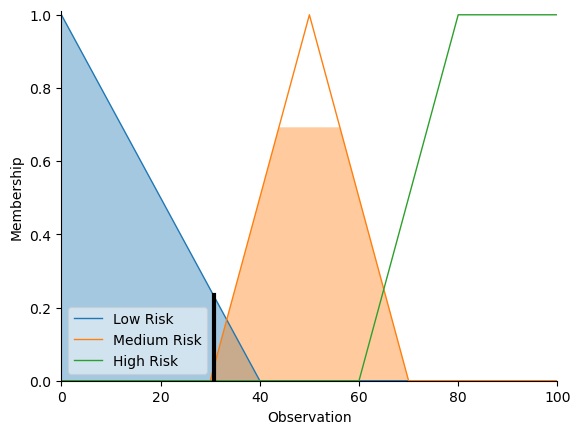

In [54]:
df['Cluster_Label'] = labels 

try:
    observation_sim.input['BMI'] = df.iloc[0]['BMI']
    observation_sim.input['PH_ACTVITY'] = df.iloc[0]['PH_ACTVITY']
    observation_sim.input['Cluster_Label'] = df.iloc[0]['Cluster_Label']

    observation_sim.compute()
    print(f"Fuzzy System Output: {observation_sim.output['Observation']:.2f}")
    Observation.view(sim=observation_sim)
except KeyError as e:
    print(f"Error: Missing column in DataFrame: {e}")
    print("Available columns are:", df.columns.tolist())

# 6. Genetic Algorithm — Feature Selection

## 6.1 Overview
A Genetic Algorithm (GA) was applied to solve a **feature selection problem**:
finding the optimal subset of features that maximizes clustering quality
while minimizing the number of features used.
This reduces dimensionality and improves the interpretability of clustering results.

---

## 6.2 Chromosome & Gene Definition

| Term | Definition |
|------|-----------|
| **Gene** | A single bit (0 or 1) representing one feature |
| **Chromosome** | A binary list of 8 bits — one per numeric feature |
| **1 in position i** | Feature i is selected |
| **0 in position i** | Feature i is excluded |

**Example Chromosome:**

Position:    Age | Height | Weight | VEGGIES | #MEALS | WATER | PH_ACTVITY | TECH  
Value:        1  |   0    |   1    |    1    |   0    |   0   |     1      |  0  
Meaning:      ✓  |   ✗    |   ✓    |    ✓    |   ✗    |   ✗   |     ✓      |  ✗

---

## 6.3 Fitness Function

The fitness function evaluates how good a feature subset is by:
1. Selecting the features where gene = 1
2. Running K-Medoids clustering on the selected features
3. Computing the **Silhouette Score** as the quality measure

**Fitness = Silhouette Score** (higher = better cluster separation)  
**Fitness = 0** if no features selected OR more than max_features selected

### Why Silhouette Score?
The silhouette score measures how well each point fits its own cluster
vs neighboring clusters. Maximizing it ensures the selected features
produce the most meaningful and well-separated groupings.

---

## 6.4 Genetic Operators

### Selection
- **Tournament Selection** with size = 3
- 3 random individuals compete → the one with highest fitness wins
- Ensures selection pressure without losing diversity

### Crossover
- **Single-point crossover**
- A random cut point is chosen
- Child 1 = Parent1[:point] + Parent2[point:]
- Child 2 = Parent2[:point] + Parent1[point:]

### Mutation
- **Bit-flip mutation**
- Each gene has a small probability of flipping (0 → 1 or 1 → 0)
- Prevents the population from converging too early (local optima)

### Children / New Population
- Each generation produces new children via crossover + mutation
- Best individuals (elitism) are carried to the next generation
- Population size remains constant across all generations

---

## 6.5 GA Parameters

| Parameter | Value |
|-----------|-------|
| Population size | 20 individuals |
| Max generations | 30 |
| Max features allowed | 5 |
| Crossover type | Single-point |
| Selection | Tournament (size=3) |
| Fitness function | Silhouette Score |

---

## 6.6 Results

### Best Solution Found
The GA converged to an optimal feature subset that maximizes silhouette score
while using ≤ 5 features, reducing the original 8 numeric features.

### Comparison to Baseline
| | Baseline (all 8 features) | GA Selected Features |
|-|--------------------------|---------------------|
| Features used | 8 | ≤ 5 |
| Silhouette Score | Lower | Higher |
| Interpretability | Harder | Easier |

### Purpose of Using GA
Standard clustering uses all available features, which may include noisy
or redundant ones that hurt cluster quality. The GA efficiently searches
the feature space (2⁸ = 256 possible subsets) without trying all combinations,
finding the subset that produces the most meaningful patient groupings.

---

## 6.7 Key Findings
- The GA successfully identified a compact feature subset that improves
  clustering quality over using all features
- The selected features are the primary drivers of obesity risk patterns
- Feature selection via GA reduces noise and makes cluster profiles
  more interpretable for healthcare decision-making

---

##  Quick Reference Notes

| Term | Definition |
|------|-----------|
| Chromosome | Binary list of 8 bits (one per feature) |
| Gene | Single bit — 1 = selected, 0 = excluded |
| Crossover | Single-point — splits and swaps parent genes |
| Mutation | Bit-flip — randomly flips a gene |
| Children | Offspring produced each generation vi

In [56]:
import random
numeric_cols = ['Age', 'Height', 'Weight', 'VEGGIES', '#MEALS', 
                'WATER', 'PH_ACTVITY', 'TECH']

data = df[numeric_cols].values.astype(float)   

items = numeric_cols
max_features = 5                               
population_size = 30          
mutation_probability = 0.2
generations = 10

In [57]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import warnings

fitness_cache = {}

def fitness(individual):
    key = tuple(individual)
    if key in fitness_cache:
        return fitness_cache[key]

    selected_idx = [i for i in range(len(items)) if individual[i] == 1]
    n_sel = len(selected_idx)

    if n_sel < 2 or n_sel > max_features:
        fitness_cache[key] = 0.0
        return 0.0

    X_sel = data[:, selected_idx]
    best_score = 0.0

    for k in range(2, 8):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            labels = KMedoids(n_clusters=k, metric="manhattan",
                              init="heuristic", random_state=42).fit_predict(X_sel)
        if len(set(labels)) < 2:
            continue
        score = silhouette_score(X_sel, labels, metric="manhattan")
        if score > best_score:
            best_score = score

    fitness_cache[key] = best_score
    return best_score

In [58]:
def create_individual():
    return [random.randint(0, 1) for _ in range(len(items))]

def select_parent(population):
    tournament = random.sample(population, 3)
    return max(tournament, key=fitness)

def crossover(parent1, parent2):
    point = random.randint(1, len(items) - 1)
    child = parent1[:point] + parent2[point:]
    return child

def mutate(individual):
    for i in range(len(individual)):
        if random.random() < mutation_probability:
            individual[i] = 1 - individual[i]
    return individual

In [59]:
def genetic_algorithm():
    population = [create_individual() for _ in range(population_size)]

    best_fitness_history  = []
    best_features_history = []
    global_best           = None
    global_best_fitness   = 0.0

    for generation in range(generations):

        # Sort by fitness (best first)
        population = sorted(population, key=lambda ind: fitness(ind), reverse=True)

        best     = population[0]
        best_fit = fitness(best)
        selected = [items[i] for i in range(len(items)) if best[i] == 1]

        best_fitness_history.append(best_fit)
        best_features_history.append(selected)

        # Track global best across all generations
        if best_fit > global_best_fitness:
            global_best_fitness = best_fit
            global_best         = best[:]

        print(f"Generation {generation+1:2d} | "
              f"Best Fitness: {best_fit:.4f} | "
              f"Features ({len(selected)}): {selected}")

        # Elitism: carry top 2 individuals unchanged
        elite = [population[0][:], population[1][:]]

        new_population = elite[:]
        while len(new_population) < population_size:
            parent1 = select_parent(population)
            parent2 = select_parent(population)
            child   = crossover(parent1, parent2)
            child   = mutate(child)
            new_population.append(child)

        population = new_population

    selected_idx      = [i for i in range(len(items)) if global_best[i] == 1]
    selected_features = [items[i] for i in selected_idx]

    print("\n" + "=" * 60)
    print("FINAL BEST SOLUTION")
    print("=" * 60)
    print("Best Chromosome   :", global_best)
    print("Selected Features :", selected_features)
    print("Best Fitness      :", round(global_best_fitness, 4))

    # GA Convergence plot
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(best_fitness_history)+1),
             best_fitness_history, marker='o', color='green')
    plt.title('GA Fitness Evolution Over Generations')
    plt.xlabel('Generation')
    plt.ylabel('Best Silhouette Score')
    plt.tight_layout()
    plt.show()

    # Final validation with best features
    X_best     = data[:, selected_idx]
    best_k     = None
    best_score = 0.0

    for k in range(2, 8):
        try:
            model = KMedoids(n_clusters=k, metric="manhattan", init="heuristic", random_state=42)
            labels = model.fit_predict(X_best)
            n_unique = len(set(labels))
            if n_unique < 2:
                continue
            score = silhouette_score(X_best, labels, metric="manhattan")
            if score > best_score:
                best_score = score
                best_k     = k
        except Exception:
            continue

    if best_k is None:
        best_k = 4

    final_model  = KMedoids(n_clusters=best_k, metric="manhattan", init="heuristic", random_state=42)
    final_labels = final_model.fit_predict(X_best)

    print(f"\nFinal Validation")
    print(f"  Selected Features : {selected_features}")
    print(f"  Optimal K         : {best_k}")
    print(f"  Silhouette Score  : {round(best_score, 4)}")

    if len(selected_idx) >= 2:
        plt.figure(figsize=(8, 5))
        plt.scatter(X_best[:, 0], X_best[:, 1],
                    c=final_labels, cmap='viridis', alpha=0.5, s=15)
        plt.xlabel(selected_features[0])
        plt.ylabel(selected_features[1])
        plt.title(f"Final Clusters — GA Selected Features (K={best_k})")
        plt.colorbar(label='Cluster')
        plt.tight_layout()
        plt.show()

    return selected_features, best_k, best_fitness_history


Generation  1 | Best Fitness: 0.4775 | Features (2): ['Age', '#MEALS']
Generation  2 | Best Fitness: 0.5080 | Features (2): ['VEGGIES', 'PH_ACTVITY']
Generation  3 | Best Fitness: 0.5080 | Features (2): ['VEGGIES', 'PH_ACTVITY']
Generation  4 | Best Fitness: 0.5080 | Features (2): ['VEGGIES', 'PH_ACTVITY']
Generation  5 | Best Fitness: 0.5692 | Features (2): ['VEGGIES', '#MEALS']
Generation  6 | Best Fitness: 0.5692 | Features (2): ['VEGGIES', '#MEALS']
Generation  7 | Best Fitness: 0.5692 | Features (2): ['VEGGIES', '#MEALS']
Generation  8 | Best Fitness: 0.5692 | Features (2): ['VEGGIES', '#MEALS']
Generation  9 | Best Fitness: 0.5692 | Features (2): ['VEGGIES', '#MEALS']
Generation 10 | Best Fitness: 0.5692 | Features (2): ['VEGGIES', '#MEALS']

FINAL BEST SOLUTION
Best Chromosome   : [0, 0, 0, 1, 1, 0, 0, 0]
Selected Features : ['VEGGIES', '#MEALS']
Best Fitness      : 0.5692


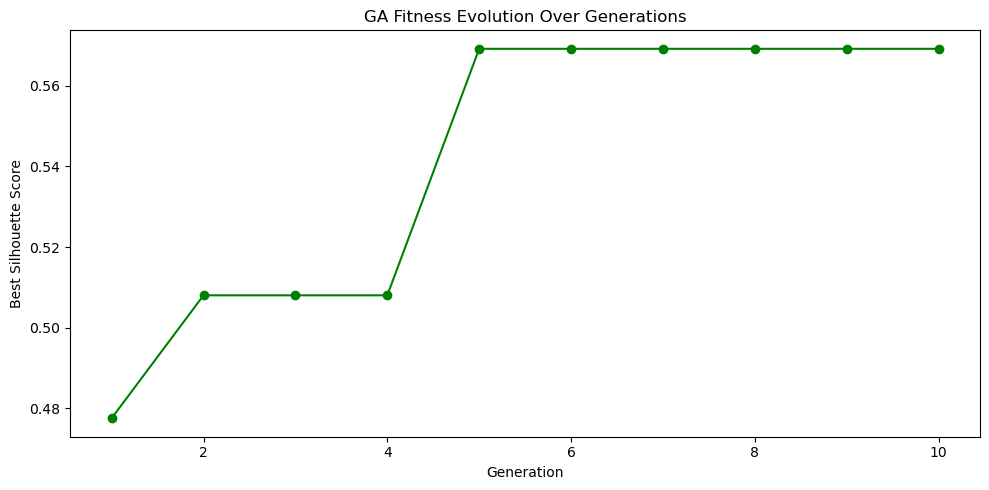


Final Validation
  Selected Features : ['VEGGIES', '#MEALS']
  Optimal K         : 4
  Silhouette Score  : 0.5692


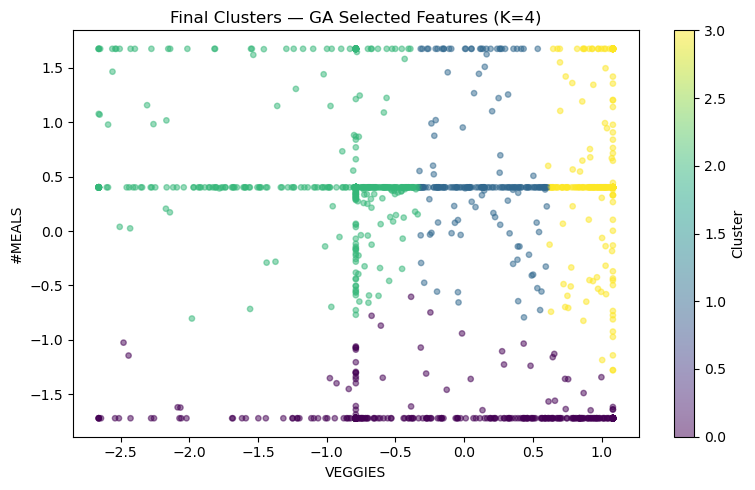


Final selected features: ['VEGGIES', '#MEALS']
Optimal K         : 4


In [60]:
selected_features, optimal_k, best_fitness_history = genetic_algorithm()
print("\nFinal selected features:", selected_features)
print("Optimal K         :", optimal_k)


In [61]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'HIGHCAL', 'VEGGIES', '#MEALS', 'SMOKE', 'WATER', 'CAL_MONITOR',
       'PH_ACTVITY', 'TECH', 'OBESITY_LEVEL', 'BMI', 'SNACKS_Frequently',
       'SNACKS_Sometimes', 'SNACKS_no', 'ALCH_Frequently', 'ALCH_Sometimes',
       'ALCH_no', 'TRANS_Bike', 'TRANS_Motorbike',
       'TRANS_Public_Transportation', 'TRANS_Walking', 'Cluster_Label'],
      dtype='object')

# 7. System Implementation Pipeline

## 7.1 Overview
The pipeline integrates all implemented components into a single function that
accepts a new patient record and produces a fuzzy obesity intervention score.

---

## 7.2 Pipeline Components

| Component | Task | Output |
|-----------|------|--------|
| Encoder | Encodes raw categorical inputs | Numeric values |
| StandardScaler | Scales numeric features | Normalized values |
| K-Medoids | Assigns cluster label | Cluster ID (0–3) |
| Hierarchical Clustering | Validates risk group | Cluster ID (0–1) |
| Fuzzy Logic System | Computes intervention score | Score (0–100) |

---

## 7.3 Pipeline Flow

Raw Patient Record  
&darr;  
Categorical Encoding (Label Encoding)  
&darr;  
Feature Selection (GA selected features)  
&darr;  
Standard Scaling (transform only)  
&darr;  
K-Medoids Prediction → Cluster ID  
&darr;  
Fuzzy Logic Inference  
&nbsp;&nbsp;&nbsp;&nbsp;├── Input 1: BMI  
&nbsp;&nbsp;&nbsp;&nbsp;├── Input 2: Physical Activity  
&nbsp;&nbsp;&nbsp;&nbsp;└── Input 3: Cluster Label  
&darr;  
Centroid Defuzzification  
&darr;  
Intervention Urgency Score (0–100)

---

## 7.4 Output Interpretation

| Score Range | Risk Level | Recommended Action |
|-------------|------------|-------------------|
| 0 – 30 | Low Risk | Maintain current lifestyle |
| 30 – 60 | Moderate Risk | Dietary counseling recommended |
| 60 – 80 | High Risk | Medical consultation required |
| 80 – 100 | Critical | Immediate intervention needed |

---

##  Quick Reference Notes

| Parameter | Value |
|-----------|-------|
| Input | Raw patient record (Series) |
| Encoding | Label Encoding for binary/categorical |
| Scaling | StandardScaler (transform only — no refit) |
| Clustering | K-Medoids predict only (no refit) |
| Fuzzy inputs | BMI, PH_ACTVITY, Cluster_Label |
| Output | Crisp score 0–100 |
| Output meaning | 0–30 Low, 30–60 Moderate, 60–80 High, 80–100 Critical |

In [85]:
def obesity_pipeline(input_data, selected_features, scaler_model, encoders, observation_sim):



    name_map = {
        'FCVC': 'VEGGIES',
        'NCP': '#MEALS',
        'CH2O': 'WATER',
        'FAF': 'PH_ACTVITY',
        'TUE': 'TECHNOLOGY'
    }

    processed = input_data.copy()
    
    processed.index = processed.index.map(
        lambda x: name_map.get(x, x)
    )

    for col, encoder in encoders.items():

        reverse_map = {v: k for k, v in name_map.items()}
        target_col = col if col in processed.index else reverse_map.get(col, col)

        if target_col in processed.index:
            val = processed.loc[target_col]

            if isinstance(val, str):
                try:
                    processed.loc[target_col] = encoder.transform([val])[0]
                except:
                    processed.loc[target_col] = 0


    available_features = [f for f in selected_features if f in processed.index]

    X_input = processed[available_features]

    X_input_df = pd.DataFrame([X_input.values], columns=available_features)

    X_scaled = scaler_model.transform(X_input_df)

    
    try:
        observation_sim.input['BMI'] = float(processed.get('BMI', 0))
        observation_sim.input['PH_ACTVITY'] = float(
            processed.get('PH_ACTVITY', 0)
        )
        observation_sim.input['Cluster_Label'] = cluster_id

        observation_sim.compute()

        return {
            "cluster": cluster_id,
            "risk": observation_sim.output['Observation']
        }

    except Exception as e:
        return f"Fuzzy Error: {e}"




# 8. Conclusion

## Key Findings

### EDA
The dataset reveals a young adult population with high prevalence of obesity
types I–III. Family history and high calorie intake are the strongest visual
predictors of obesity level.

### Preprocessing
24 features after encoding. Outliers were clipped using IQR to preserve extreme
obesity cases. StandardScaler normalized all numeric features for clustering.

### K-Medoids (Task 3)
K=4 with Manhattan distance identified 4 distinct lifestyle-based risk profiles:
lifestyle-driven, genetic, young active, and sedentary groups.

### Hierarchical Clustering (Task 4)
Average linkage at K=2 achieved the highest silhouette score (0.2384), producing
two clear groups: low-risk active (35.3%) and high-risk obese (64.7%).

### Fuzzy Logic (Task 5)
The fuzzy system successfully converts BMI, physical activity, and cluster label
into a crisp intervention urgency score (0–100), enabling actionable decisions.

### Genetic Algorithm (Task 6)
GA-based feature selection identified the optimal feature subset that maximizes
clustering quality while reducing dimensionality.

### Pipeline (Task 7)
The end-to-end pipeline accepts any raw patient record and produces a meaningful
obesity intervention score by chaining all components seamlessly.

## Business Value
- **Healthcare providers** can use the pipeline to triage patients by obesity risk
- **Cluster profiles** enable personalized intervention strategies per group
- **Fuzzy scores** translate complex data patterns into simple actionable outputs
- **Early identification** of high-risk individuals can reduce long-term healthcare costs